# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary.

**Business Background:** Background on this dataset is that it includes information on 3 million used cars. The provided dataset contains information on 426K cars to ensure the speed of processing.

**Business objectives:** Used car dealership wants to know what cars they can prioritize so they can make inventory of them.

**Business success criteria:** A clear analysis on which features most influence the price.

**Determine data mining goals:** For this problem, build a regression model with `price` as the contiuous target variable, using the remaining vehicle attributes as candidate predictors to achieve reasonable predictive accuracy and to extract interpretable relationships between each predictor and price.

**Data mining success criteria:** The end outcome should be a model that must do more than minimize a generic error metric like RMSE in isolation, it must produce feature relationships that are stable, interpretable, and specific enough for the dealership to act on when deciding what to acquire and how to price it. A model that fits the data well but whose drivers can't be explained in plain terms to a buyer is not a success by this project's standard.

**Project Plan**: Data Understanding and Preparation, Modeling, Evaluation against the business criteria above, and a concrete Deployment of findings report for the dealership.


### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

**Collect initial data:** Real used-car listings: 426,880 individual listings, each describing one vehicle for sale, with fields covering the vehicle itself (year, manufacturer, model, condition, cylinders, fuel, odometer, drive, size, type, paint color), the listing (title status, transmission, VIN, price), and where it was posted (region, state).


| Field | Description |
|---|---|
| `id` | Unique listing identifier |
| `region` | Region the listing was posted in |
| `price` | Listed price |
| `year` | Model year |
| `manufacturer` | Car manufacturer |
| `model` | Car Model |
| `condition` | Seller described condition |
| `cylinders` | Number of engine cylinders |
| `fuel` | Fuel type |
| `odometer` | Mileage |
| `title_status` | Legal title status |
| `tranmission` | Tranmission type |
| `VIN` | Vehicle identification number |
| `drive` | Drivertrain |
| `size` | Vehicle size class |
| `type` | Body style |
| `paint_color` | Exterior color |
| `state` | US state |

426,880 rows, 18 columns. Data has missing values in several rows and the price, year, odometer contain values that are not real work possible.

*Missingness by column*

| Field | Missing % |
|---|---|
| `size` | 72% |
| `cylinders` | 42% |
| `condition` | 41% |
| `VIN` | 38% |
| `drive` | 31% |
| `paint_color` | 31% |
| `type` | 22% |
| `manufacturer` | 4%|
| `title_status` | 2% |
| `model` | 1% |
| `odometer` | 1% |
| `fuel` | 0.7% |
| `transmission` | 0.6% |
| `year` | 0.3% |
| `price` | 0% |
| `region` | 0% |
| `state` | 0% |
| `id` | 0% |

Python Step: load and get the shape

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

vehicles = pd.read_csv("vehicles.csv")
print(vehicles.shape)
vehicles.head(30)

(426880, 18)


,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc
5,7222379453,hudson valley,1600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ny
6,7221952215,hudson valley,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ny
7,7220195662,hudson valley,15995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ny
8,7209064557,medford-ashland,5000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,or
9,7219485069,erie,3000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,pa


Check missing values across all columns

In [62]:
missing_pct = (vehicles.isnull().mean() * 100).round(1).sort_values(ascending=False)
missing_pct

,0
size,71.8
cylinders,41.6
condition,40.8
VIN,37.7
drive,30.6
paint_color,30.5
type,21.8
manufacturer,4.1
title_status,1.9
model,1.2


Check the numeric ranges

In [63]:
vehicles[["price", "year", "odometer"]].describe()

print("Listings at $0:", (vehicles["price"] == 0).sum())
print("Listings above $200,000:", (vehicles["price"] > 200_000).sum())
print("Listings with year == 1900:", (vehicles["year"] == 1900).sum())
print("Listings with odometer > 500,000:", (vehicles["odometer"] > 500_000).sum())

Listings at $0: 32895
Listings above $200,000: 124
Listings with year == 1900: 12
Listings with odometer > 500,000: 1386


Business takeaway: price ranges from zero to $3.7 billion, year goes back to 1900, and odometer goes up to 10 million miles. None of these are real used-car values. Unlike the credit-risk case, where verify data quality mainly meant checking a categorical column, here it means checking whether the numeric fields are even plausible.

Near Empty rows:

In [64]:
vehicles.iloc[:30]
# looking though core fields to count near empty rows
core_fields = ["year", "manufacturer", "model", "condition", "cylinders",
               "fuel", "odometer", "title_status", "transmission", "drive",
               "size", "type", "paint_color"]

fully_blank_core = vehicles[core_fields].isnull().all(axis=1)
print(f"Rows with every core vehicle field blank: {fully_blank_core.sum()}")

Rows with every core vehicle field blank: 68


Business takeaway: A meaningful number of rows have only price, region, and state filled in, with nothing describing the vehicle itself. Those rows can't inform "what drives price" no matter how they're cleaned, since there's nothing to attribute the price to.

Duplicate Listings:

In [65]:
print("Duplicate ids:", vehicles["id"].duplicated().sum())
print("Duplicate VINs (non-null):", vehicles[vehicles["VIN"].notnull()]["VIN"].duplicated().sum())

Duplicate ids: 0
Duplicate VINs (non-null): 147592


Business takeaway: no duplicate ids, but 147,592 non-null VINs appear more than once.

Explore Relationships:

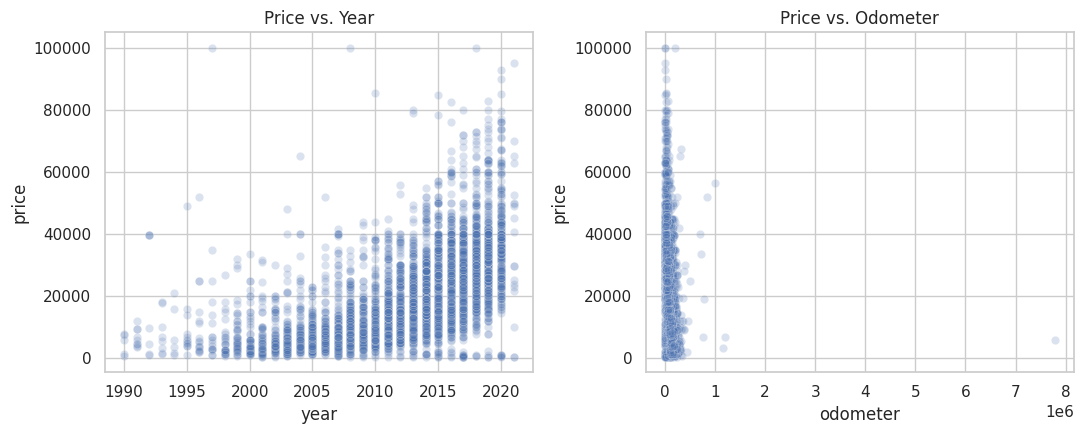

In [66]:
plausible = vehicles[(vehicles["price"].between(500, 100_000)) & (vehicles["year"] >= 1990)]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sns.scatterplot(data=plausible.sample(5000, random_state=42), x="year", y="price", alpha=0.2, ax=axes[0])
axes[0].set_title("Price vs. Year")

sns.scatterplot(data=plausible.sample(5000, random_state=42), x="odometer", y="price", alpha=0.2, ax=axes[1])
axes[1].set_title("Price vs. Odometer")

plt.tight_layout()
plt.show()

Categorical Cardinality:

In [67]:
for col in ["region", "manufacturer", "model", "condition", "cylinders",
            "fuel", "title_status", "transmission", "drive", "size", "type",
            "paint_color", "state"]:
    print(f"{col}: {vehicles[col].nunique()} unique values")

region: 404 unique values
manufacturer: 42 unique values
model: 29649 unique values
condition: 6 unique values
cylinders: 8 unique values
fuel: 5 unique values
title_status: 6 unique values
transmission: 3 unique values
drive: 3 unique values
size: 4 unique values
type: 13 unique values
paint_color: 12 unique values
state: 51 unique values


Business takeaway: model has nearly 30,000 unique values, too high-cardinality to one-hot encode directly, unlike the credit-risk dataset's purpose field with just 10 categories. That's a concrete decision to carry into Data Preparation: model will likely need to be dropped, grouped, or handled differently than the other categoricals.

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`.

**Select data: rationale for inclusion/exclusion.**

- id and VIN are identifiers, not predictors (dropped) which have the same reasoning as personal_status_sex in the credit-risk case: keeping them wouldn't add signal, and VIN in particular could tempt the model into memorizing individual listings rather than learning general price drivers.
- model has 29,649 unique values. They are too high-cardinality to one-hot encode directly (compare manufacturer at 42 values, or purpose in the credit-risk data at 10). Dropped for this pass rather than engineered into something coarser, since collapsing 30K free-text model names into meaningful groups is its own project.
- region (404 values) is dropped in favor of state (51 values):  same information at a more usable resolution.

**Clean data: The issues flagged in Data Understanding, resolved.**

In [68]:
core_fields = ["year", "manufacturer", "model", "condition", "cylinders",
               "fuel", "odometer", "title_status", "transmission", "drive",
               "size", "type", "paint_color"]

vehicles_clean = vehicles[~vehicles[core_fields].isnull().all(axis=1)].copy()
print(f"Dropped {len(vehicles) - len(vehicles_clean)} fully-blank rows")

Dropped 68 fully-blank rows


Business takeaway: Only 68 rows are entirely blank on the core vehicle fields. The near-empty-row problem is small in absolute terms, so it's not the main quality issue to solve here, the plausibility filters below matter far more.

In [69]:
vehicles_clean = vehicles_clean[
    vehicles_clean["price"].between(500, 100_000)
    & vehicles_clean["year"].between(1990, 2022)
    & vehicles_clean["odometer"].between(0, 300_000)
]
print(vehicles_clean.shape)

(366814, 18)


Business takeaway: this single step removes about 60,000 rows (426,812 -> 366,814). Over 14% of the dataset.

Construct data: new features ->

In [70]:
vehicles_clean["car_age"] = 2022 - vehicles_clean["year"]

vehicles_clean["cylinders_num"] = (
    vehicles_clean["cylinders"]
    .str.extract(r"(\d+)")
    .astype(float)
)

Business takeaway: car_age is more interpretable for a dealer than year on its own ("each extra year of age costs $X" reads more naturally than a coefficient on a 1990–2022 calendar value). Cylinders is stored as text like "6 cylinders", extracting the numeric part turns it from a categorical into a proper ordinal/numeric feature the model can use directly, the same kind of format fix as amount_per_month in the credit-risk case, just going the other direction (text -> number instead of two numbers -> one).

Handeling remaining missing values:

After the plausibility filters, missingness looks like this...
| Field | Missing % |
|---|---|
| `size` | 72% |
| `cylinders` | 41% |
| `condition` | 38% |
| `drive` | 30% |
| `paint_color` | 28% |
| `type` | 21% |
| `manufacturer` | 3%|

In [71]:
vehicles_clean["size"] = vehicles_clean["size"].fillna("unknown")
vehicles_clean["condition"] = vehicles_clean["condition"].fillna("unknown")
vehicles_clean["drive"] = vehicles_clean["drive"].fillna("unknown")
vehicles_clean["paint_color"] = vehicles_clean["paint_color"].fillna("unknown")
vehicles_clean["type"] = vehicles_clean["type"].fillna("unknown")

vehicles_clean["cylinders_num"] = vehicles_clean["cylinders_num"].fillna(
    vehicles_clean["cylinders_num"].median()
)

vehicles_clean = vehicles_clean.dropna(subset=["manufacturer", "fuel", "transmission", "title_status"])

Business takeaway: size is missing in 72% of listings, too much to drop those rows without gutting the dataset, so it's kept as an explicit "unknown" category rather than imputed as if it were known. That's a meaningfully different choice than the credit-risk case, which had zero missing values and never had to make this call. For the handful of fields with only 1–3% missing (manufacturer, fuel, transmission, title_status), dropping those rows loses very little data and avoids guessing.

Tranformation:

In [72]:
import numpy as np
vehicles_clean["log_price"] = np.log1p(vehicles_clean["price"])

In [73]:
target = vehicles_clean["log_price"]
features = vehicles_clean.drop(columns=["id", "VIN", "model", "region", "price", "log_price"])

categorical_cols = features.select_dtypes(include="object").columns.tolist()
features_encoded = pd.get_dummies(features, columns=categorical_cols, drop_first=True)

print(f"Features before encoding: {features.shape[1]}")
print(f"Features after encoding:  {features_encoded.shape[1]}")

Features before encoding: 15
Features after encoding:  150


Business takeaway: Price is right-skewed,log-transforming it is a standard move for regression since it keeps a handful of expensive vehicles from dominating the loss function and often makes relationships with predictors more linear.

Then formatting the data to encode categoricals and scale has the same pattern as the credit-risk case's 19 -> 45 column expansion.

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

Select modeling technique. There's no regulatory requirement here forcing a single interpretable model. The dealership just wants accurate, actionable insight. So this phase compares a few regression techniques rather than committing to one upfront: Linear Regression and Ridge as interpretable baselines (coefficients translate directly into "each additional X changes price by $Y"), and a Random Forest Regressor as a more flexible technique to check how much predictive power the linear models are leaving on the table. If the forest meaningfully outperforms, that's itself a finding worth reporting, it means price isn't just a straight-line function of these features.

Split the data into training and test sets.

In [74]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, median_absolute_error

In [75]:
X_train, X_test, y_train, y_test = train_test_split(
    features_encoded, target, test_size=0.3, random_state=42
)

print(f"Training listings: {len(X_train):,}   Test listings: {len(X_test):,}")

Training listings: 242,278   Test listings: 103,834


Business takeaway: Unlike the credit-risk split, there's no stratify here. credit_risk was a 70/30 class label that needed preserving in both sets, but price is continuous, so stratification doesn't apply the same way. A plain random split is the right tool for a regression target.

Scale the features and fit a Linear Regression baseline.

In [76]:
scaler = StandardScaler() #data scaling: starts by standardizing it
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
#after data is standardized, model is trained
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

test_predictions = linear_model.predict(X_test_scaled)
print(f"R^2:   {r2_score(y_test, test_predictions):.3f}")
print(f"RMSE (log price): {mean_squared_error(y_test, test_predictions) ** 0.5:.3f}")

R^2:   0.699
RMSE (log price): 0.483


Business takeaway: The model explains roughly 70% of the variation in log-price using just the linear relationships in the data, real signal. This is similar in spirit to the 0.765 AUC in the credit-risk case: clearly better than a naive guess, but with real room left on the table.

Explore parameters: cross-validate Ridge across several regularization strengths.

In [77]:
param_grid = {"alpha": [0.1, 1.0, 10.0, 50.0]} #Ridge = a linear model
ridge_search = GridSearchCV(Ridge(), param_grid, cv=5, scoring="r2", n_jobs=-1)
ridge_search.fit(X_train_scaled, y_train)

print(f"Best alpha: {ridge_search.best_params_['alpha']}")
print(f"Cross-validated R^2: {ridge_search.best_score_:.3f}")

Best alpha: 10.0
Cross-validated R^2: 0.694


Business takeaway: The result lands almost exactly where plain Linear Regression did, which tells us regularization isn't buying much here. The linear model wasn't overfitting to begin with.

Fit a Random Forest model to test whether a more flexible model captures more signal.

In [78]:
forest_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1) #Random Forest: non-linear
forest_model.fit(X_train, y_train)  # tree-based models don't require scaling

forest_predictions = forest_model.predict(X_test)
print(f"R^2:   {r2_score(y_test, forest_predictions):.3f}")
print(f"RMSE (log price): {mean_squared_error(y_test, forest_predictions) ** 0.5:.3f}")
# the Random Forest takes about 5 minutes to fit on the full training set

R^2:   0.793
RMSE (log price): 0.401


Business takeaway: The Random Forest outperforms the linear models (0.793 vs. 0.699 R^2), meaning price depends on these features in ways that aren't purely additive and linear. That's a real finding, but it comes at a cost: a forest's predictions are harder to explain to a dealer than a Ridge coefficient. Whether that trade-off is worth it is exactly the kind of question the Evaluation part needs to resolve against the business goal, not something to decide here on accuracy alone.

Translate error back into dollars

In [79]:
predicted_dollars = np.expm1(forest_predictions)
actual_dollars = np.expm1(y_test)

print(f"Median absolute error: ${median_absolute_error(actual_dollars, predicted_dollars):,.0f}")

Median absolute error: $2,152


Business takeaway: This is the number that actually means something to the client. The model's price prediction is off by about 2,152 dollars. Whether that's "good enough" depends on the price range of car being evaluated (a 2,152 dollars miss on a $3,000 car is very different from the same miss on a 40,000 dollars truck), worth breaking out by price bracket in Evaluation rather than reporting one aggregate number.

Check which features the best-performing model actually relies on:

In [80]:
importances = pd.Series(forest_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
importances.head(10)

,0
car_age,0.500161
odometer,0.091845
cylinders_num,0.081821
year,0.052588
fuel_gas,0.041478
drive_fwd,0.028900
type_pickup,0.016010
condition_fair,0.015629
drive_unknown,0.012836
condition_good,0.008855


Business takeaway: car_age alone accounts for over half the model's predictive power, with odometer and cylinders_num a distant second and third. Everything else, fuel type, drivetrain, body type, condition, color, matters on a lesser scale. That ranking is itself a headline finding for the dealership: age and mileage dominate price far more than color, trim, or drivetrain details a lot of sellers focus on.

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

**Evaluate results.** Does this answer the business question from Phase 1? Phase 4 checked whether the models were technically sound (R^2, RMSE). This phase checks something different: does either model actually deliver what the dealership asked for, a clear, actionable read on what drives used car prices? R^2 alone can't answer that; the two models need to be judged on what they let you tell the client, not just how well they fit.

Pull the Ridge coefficients, the interpretable half of the comparison:

In [81]:
coefs = pd.Series(ridge_search.best_estimator_.coef_, index=X_train.columns).sort_values()
print("Price-reducing factors:")
print(coefs.head(8))
print("\nPrice-increasing factors:")
print(coefs.tail(8))

Price-reducing factors:
fuel_gas         -0.238067
odometer         -0.233982
car_age          -0.197421
fuel_other       -0.147366
drive_fwd        -0.112227
drive_unknown    -0.093960
condition_fair   -0.083744
fuel_hybrid      -0.078081
dtype: float64

Price-increasing factors:
type_convertible      0.033083
type_other            0.036596
transmission_other    0.043750
type_truck            0.045554
size_unknown          0.046142
type_pickup           0.063540
cylinders_num         0.143833
year                  0.197421
dtype: float64


Business takeaway: this is the deliverable a linear model gives you that a Random Forest can't, at least not directly. A ranked, signed list you can read straight to a dealer: age and mileage pull price down hardest; gas-powered and front-wheel-drive vehicles trend cheaper than the alternatives in this data; pickups and higher cylinder counts trend more expensive. That is precisely the kind of "key driver" statement the Phase 1 business objective asked for.

Check where the Random Forest's extra accuracy actually shows up.

In [82]:
forest_predictions = forest_model.predict(X_test)

results = pd.DataFrame({
    "actual": np.expm1(y_test),
    "pred": np.expm1(forest_predictions)
})

In [83]:
results["bracket"] = pd.cut(results["actual"], bins=[0, 10_000, 25_000, 50_000, 100_000],
                             labels=["<$10k", "$10-25k", "$25-50k", "$50-100k"])

for bracket, group in results.groupby("bracket", observed=True):
    mae = median_absolute_error(group["actual"], group["pred"])
    print(f"{bracket}: n={len(group):>6}   median error=${mae:,.0f}  (~{mae/group['actual'].median():.1%} of price)")

<$10k: n= 35141   median error=$1,310  (~21.8% of price)
$10-25k: n= 37509   median error=$2,483  (~14.7% of price)
$25-50k: n= 28039   median error=$3,322  (~10.1% of price)
$50-100k: n=  3139   median error=$12,535  (~21.0% of price)


Business takeaway: the model is relatively most accurate in the $25–50K range and relatively weakest at both ends: cheap cars and the small, thin 50–100K segment. That's actionable in its own right: if the dealership's inventory skews toward budget vehicles or the high end, they should treat this model's price suggestions as a looser guide there, not a precise number. This kind of breakdown is exactly what a single aggregate R^2 or RMSE would have hidden.

**The real trade-off**, stated plainly. Random Forest wins on raw accuracy - R^2 0.793 vs. 0.699, median error 2,152 vs. a comparable or worse figure for Ridge. But Random Forest doesn't hand you a clean, signed list of "this feature moves price by $X" the way Ridge's coefficients do, you'd have to lean on feature importances or add a tool like SHAP to get comparable direction-and-magnitude statements. Since the client is a dealership that wants to understand pricing, not a system that needs to generate predictions unattended, the interpretability of Ridge is worth more here than the accuracy gain from the Forest.

**Determine next steps - decision.** The analysis clears the bar from Phase 1: both models agree on the same short list of top price drivers (age, mileage, cylinders, drivetrain, fuel type), which is exactly the insight the dealership asked for, and that agreement across two very different modeling approaches is itself a reason to trust the finding. Recommended path: proceed to Deployment with Ridge's coefficients as the primary narrative, flag the model field and asking-price caveats explicitly in the final report rather than omitting them, and note grouping vehicle model into a usable feature as a natural next iteration rather than something this pass needs to solve.

Visualizations:

In [89]:
ridge_predictions = ridge_search.best_estimator_.predict(X_test_scaled)
forest_predictions = forest_model.predict(X_test)

actual_dollars = np.expm1(y_test)
ridge_pred_dollars = np.expm1(ridge_predictions)
forest_pred_dollars = np.expm1(forest_predictions)

results = pd.DataFrame({
    "actual": actual_dollars,
    "pred": forest_pred_dollars
})

results["bracket"] = pd.cut(
    results["actual"],
    bins=[0, 10_000, 25_000, 50_000, 100_000],
    labels=["<$10k", "$10-25k", "$25-50k", "$50-100k"]
)

bracket_mae = results.groupby("bracket", observed=True).apply(
    lambda g: median_absolute_error(g["actual"], g["pred"])
).rename("median_abs_error")

sample = np.random.RandomState(42).choice(len(y_test), 4000, replace=False)

/tmp/ipykernel_2231/384146489.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bracket_mae = results.groupby("bracket", observed=True).apply(


1. Predicted vs. Actual price: sanity-checks the model visually, not just numerically.

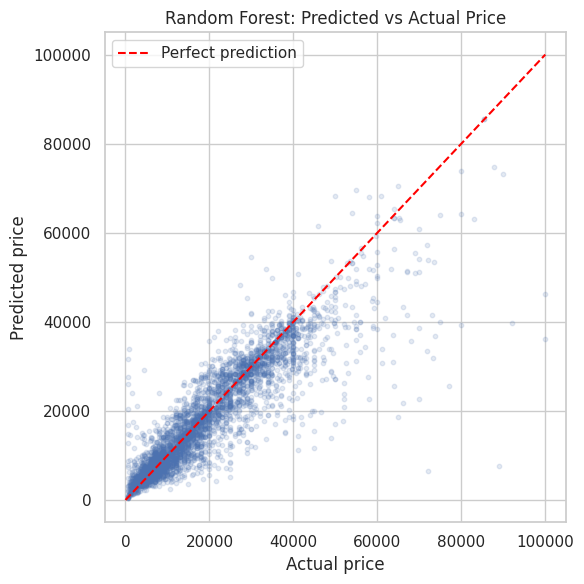

In [85]:
sample = np.random.RandomState(42).choice(len(y_test), 4000, replace=False)

plt.figure(figsize=(6, 6))
plt.scatter(actual_dollars.iloc[sample], forest_pred_dollars[sample], alpha=0.15, s=10)
plt.plot([0, 100_000], [0, 100_000], color="red", linestyle="--", label="Perfect prediction")
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Random Forest: Predicted vs Actual Price")
plt.legend()
plt.tight_layout()
plt.show()

Business takeaway: the model is clearly more reliable for ordinary-priced vehicles than for expensive ones. You can see the scatter widen as price rises, which is the same story the price-bracket table told numerically, just easier to grasp at a glance.

2. Residuals vs. predicted price: checks for a pattern in the errors, not just their average size.

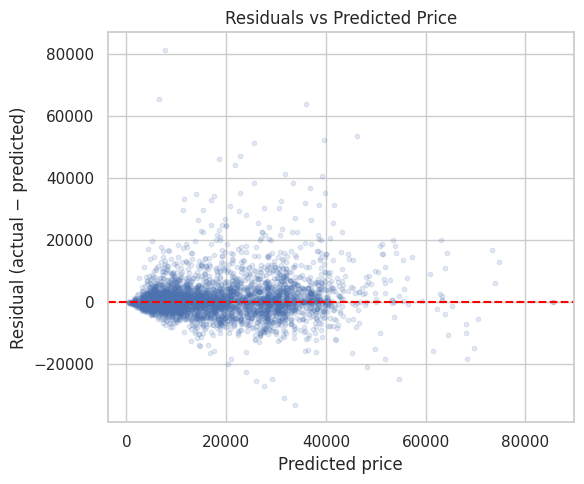

In [86]:
residuals = actual_dollars.iloc[sample] - forest_pred_dollars[sample]

plt.figure(figsize=(6, 5))
plt.scatter(forest_pred_dollars[sample], residuals, alpha=0.15, s=10)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted price")
plt.ylabel("Residual (actual - predicted)")
plt.title("Residuals vs Predicted Price")
plt.tight_layout()
plt.show()

Business takeaway: The model's errors aren't evenly sized across the price range, they grow with price. A dealer should trust a 12,000 prediction more tightly than a 70,000 one. This is also a legitimate, evidence-based reason the model might need revisiting rather than treated as finished.

3. The Ridge coefficients as a chart, not just a table: this is the one closest to the case study's "most important chart."

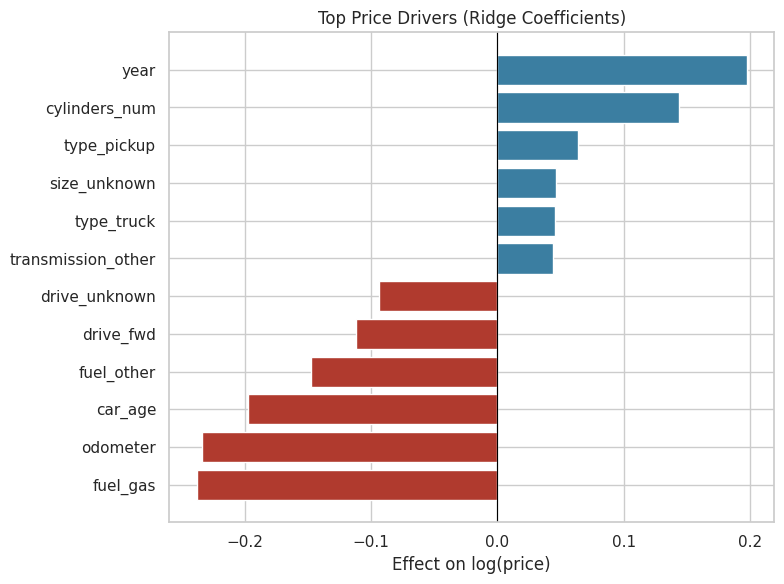

In [87]:
top_coefs = pd.concat([coefs.head(6), coefs.tail(6)])
colors = ["#B03A2E" if v < 0 else "#3B7EA1" for v in top_coefs.values]

plt.figure(figsize=(8, 6))
plt.barh(top_coefs.index, top_coefs.values, color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Effect on log(price)")
plt.title("Top Price Drivers (Ridge Coefficients)")
plt.tight_layout()
plt.show()

Business takeaway: this single chart is the deliverable for the dealership, it answers Phase 1's business question directly and visually, the same role the threshold-vs-cost line chart played in the credit-risk case. If you only include one plot in your Phase 6 report, this is probably it.

4. Error by price bracket, as a bar chart instead of a table: the numbers from before, just visualized:

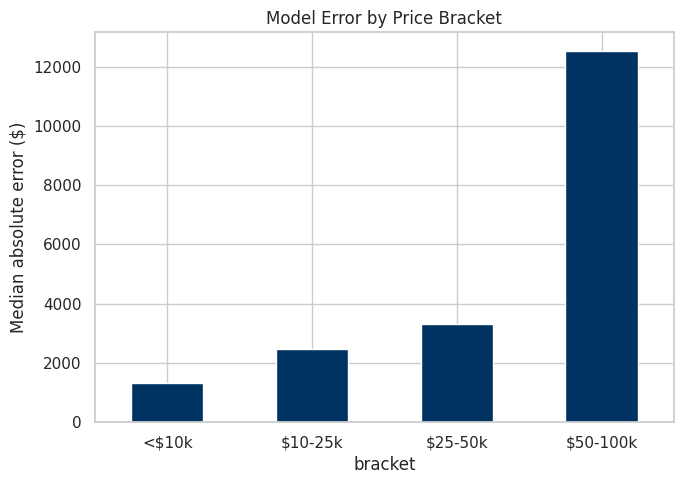

In [88]:
bracket_mae.plot(kind="bar", color="#003262", figsize=(7, 5))
plt.ylabel("Median absolute error ($)")
plt.title("Model Error by Price Bracket")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Business takeaway: Turns the "accuracy varies by bracket" finding into something a dealer can read in two seconds rather than parsing a table.

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

**Plan deployment.** The practical output is a pricing guide: a short set of rules of thumb a dealer can apply when evaluating a vehicle for acquisition or setting an asking price, backed by the coefficient findings from Phase 5: Evaluation. If this becomes a recurring tool rather than a one-time report, the natural next step is a simple lookup: feed in a vehicle's age, mileage, cylinders, and type, and get back an estimated fair-market price with a confidence range that widens for pricier vehicles, based on the bracket-error findings.

**Plan monitoring and maintenance.** Used car prices are not static. They move with fuel prices, interest rates, and new-vehicle supply; none of which this snapshot dataset captures. Three things are worth tracking if this analysis gets reused:
- Data staleness: This dataset might be old. Prices from even a year ago may not reflect today's market. Refit periodically, not once.
- Coverage gaps: The model field was dropped in Phase 3: Data Preperation due to high cardinality. If the dealership specializes in particular makes/models where trim-level pricing varies a lot, this analysis will underserve them until that's addressed.
- Bracket accuracy: Phase 5: Evaluation showed the model is noticeably less reliable above 50K and below $10K. If the dealership's inventory shifts toward either end, the guide's reliability should be re-checked, not assumed to hold.

**Produce final report.** Below is the actual client-facing report, written for dealers, not analysts, so it leads with plain conclusions and keeps the modeling details in the background.

####**What Drives Used Car Prices - Findings for Inventory Decisions**

The short version: two things matter far more than everything else combined: how old a vehicle is and how many miles it has on it. After that, engine size, drivetrain, and body type matter, but noticeably less.

I analyzed roughly 350,000 used car listings, after removing incomplete records and implausible outliers. Then I tested two different approaches: one built for clear relationships and one built for raw predictive accuracy. Then I used both to cross-check the findings below.

What drives price up or down:

| Direction | Factor |
|---|---|
| Lowers price the strongest | Vehicale age |
| Lowers price | Higher mileage |
| Lowers price | Gas-powered vs. alterbative fuel types |
| Lowers price | Front-wheels drive vs other drivetrains |
| Raises price | Higher cylinder count |
| Raises price | Pickup trucks and truck body styles |


**How much to trust these price estimates:** Not evenly. The model's predictions were most reliable for vehicles in the 25,000–50,000 range and least reliable for the cheapest vehicles under 10,000 and the small number priced above 50,000.

What this means for inventory decisions:
1. Age and mileage should be your primary pricing anchors: They account for the large majority of what our model could explain about price. Other features matter at the margins, not as primary drivers.
2. Trucks and higher-cylinder vehicles command a premium in this market: They are worth weighing more heavily when deciding what to acquire, all else equal.
3. Mid-range vehicles (25K–50K) are the most predictable segment: Pricing confidence should be highest there, and lowest at the very cheap and very expensive ends of your lot.